In [ ]:
# multiple linear regression we have two independent features 

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_index=pd.read_csv("economic_index.csv")

In [3]:
df_index.head()



,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [6]:
df_index.drop(columns=["Unnamed: 0","year","month"],axis=1,inplace=True)

In [7]:
df_index.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [8]:
df_index.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

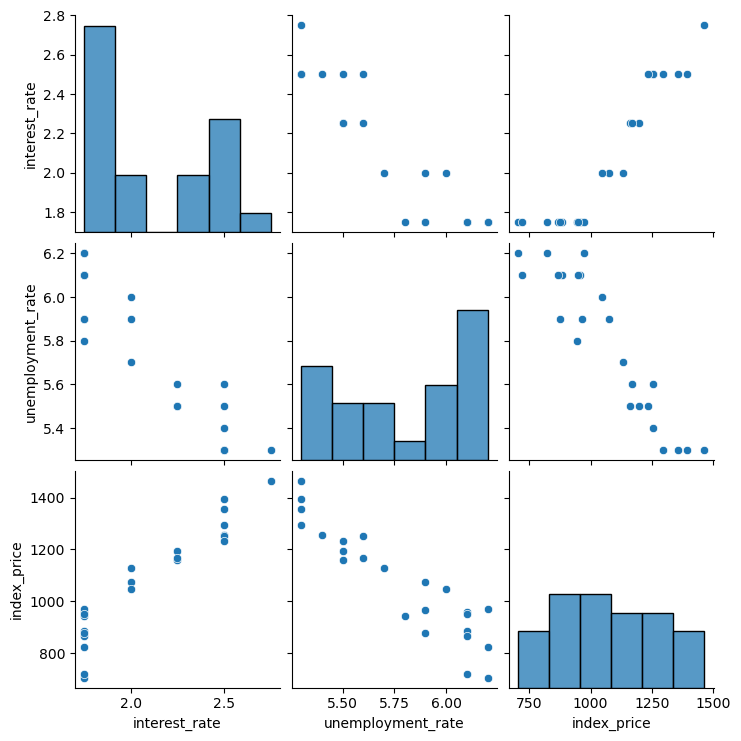

In [9]:
sns.pairplot(df_index)

In [10]:
df_index.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

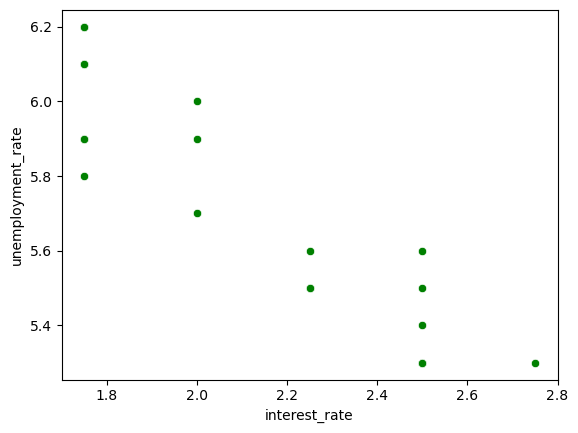

In [12]:
#visualize the datapoint more closeely
sns.scatterplot(x="interest_rate",y="unemployment_rate",data=df_index,color="green")

In [ ]:
x=df_index.iloc[:,:-1] # get all the columns except the last one
y=df_index.iloc[:,-1] # get the last column as target variable

In [14]:
x

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4
5,2.50,5.6
6,2.50,5.5
7,2.25,5.5
8,2.25,5.5
9,2.25,5.6


In [15]:
y

0     1464
1     1394
2     1357
3     1293
4     1256
5     1254
6     1234
7     1195
8     1159
9     1167
10    1130
11    1075
12    1047
13     965
14     943
15     958
16     971
17     949
18     884
19     866
20     876
21     822
22     704
23     719
Name: index_price, dtype: int64

In [16]:
from sklearn.model_selection import train_test_split
x_test,x_train,y_test,y_train=train_test_split(x,y,test_size=0.2,random_state=42)

<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

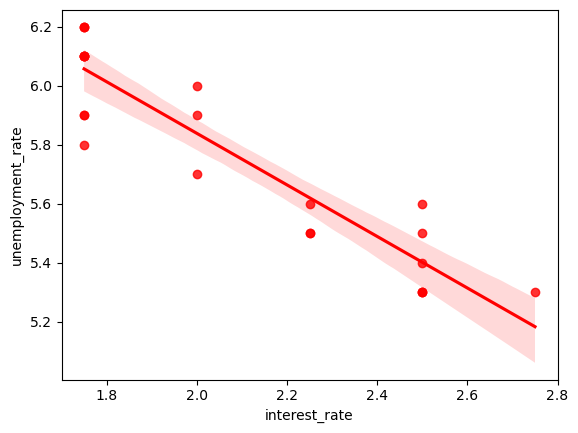

In [17]:
# this will plot data and regression
sns.regplot(x="interest_rate",y="unemployment_rate",data=df_index,color="red")

In [18]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [19]:
from sklearn.linear_model import LinearRegression
Regression=LinearRegression()
Regression.fit(x_train,y_train)

LinearRegression()

In [22]:
from sklearn.model_selection import cross_val_score
validation_score=cross_val_score(Regression,x_train,y_train,scoring="neg_mean_squared_error",cv=5)
validation_score

array([-10482.60946746,  -2620.65236686, -47306.25      ,  -3959.5125258 ,
         -336.64272212])

In [23]:
np.mean(validation_score)

np.float64(-12941.133416447668)

In [26]:
from sklearn.linear_model import LinearRegression
Regression=LinearRegression()
Regression.fit(x_train,y_train)
y_pred=Regression.predict(x_test)
y_pred

array([1172.92340426,  872.59148936, 1285.21276596,  948.34468085,
       1360.96595745, 1285.21276596, 1085.88510638,  923.09361702,
       1285.21276596, 1310.46382979,  948.34468085,  923.09361702,
        872.59148936,  923.09361702, 1147.67234043, 1010.13191489,
        847.34042553,  923.09361702, 1335.71489362])

In [29]:
from sklearn.metrics import mean_squared_error,mean_absolute_error
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print("mean_squared_error:",mse)
print("mean_absolute_error:",mae)
print("root_mean_squared_error:",rmse)

mean_squared_error: 10533.186649829642
mean_absolute_error: 81.45666293393056
root_mean_squared_error: 102.63131417764095


In [30]:
from sklearn.metrics import r2_score
r2=r2_score(y_test,y_pred)
print("r2_score:",r2)

r2_score: 0.7534459466700992


<Axes: xlabel='index_price'>

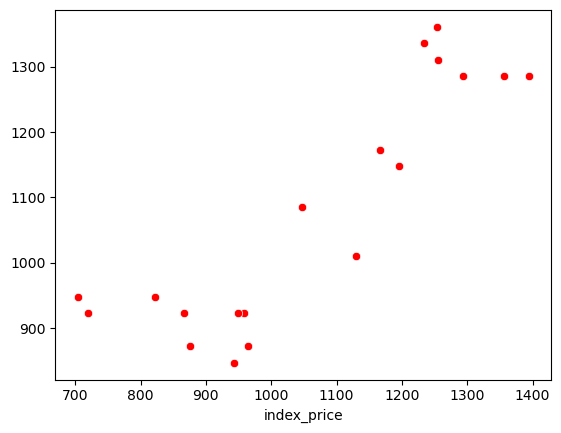

In [31]:
sns.scatterplot(x=y_test,y=y_pred,color="red")

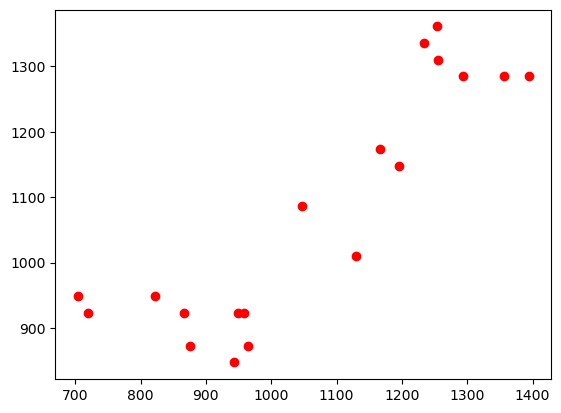

In [33]:
plt.scatter(x=y_test,y=y_pred,color="red")

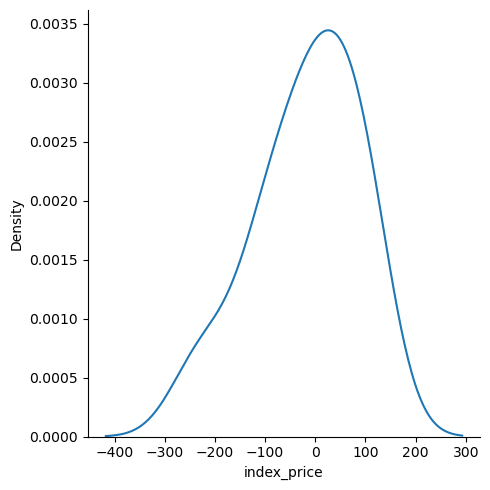

In [39]:
residuals=y_test-y_pred
sns.displot(residuals,kind="kde")

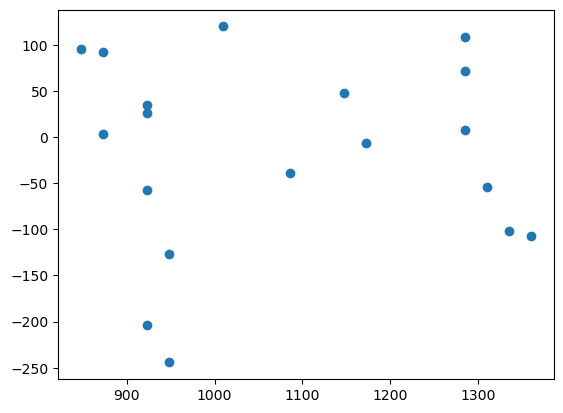

In [41]:
plt.scatter(y_pred,residuals)

In [43]:
import statsmodels.api as sm
model=sm.OLS(y_train,x_train).fit()

In [44]:
model.summary()

c:\Users\Asus\anaconda3\Lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:            index_price   R-squared (uncentered):                   0.031
Model:                            OLS   Adj. R-squared (uncentered):             -0.615
Method:                 Least Squares   F-statistic:                            0.04787
Date:                Sun, 19 Apr 2026   Prob (F-statistic):                       0.954
Time:                        22:32:59   Log-Likelihood:                         -42.159
No. Observations:                   5   AIC:                                      88.32
Df Residuals:                       3   BIC:                                      87.54
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1           281.4363   2425.043      0.116      0.915   -7436.132    7999.005
x2            87.4723   2425.043      0.036      0.973   -7630.096    7805.041
==============================================================================
Omnibus:                          nan   Durbin-Watson:                   0.001
Prob(Omnibus):                    nan   Jarque-Bera (JB):                0.686
Skew:                          -0.814   Prob(JB):                        0.709
Kurtosis:                       2.199   Cond. No.                         7.43
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [45]:
print("coefficients:",Regression.coef_)

coefficients: [281.43632327  87.472251  ]
